<h1 style='font-size:40px;background:PINK; border:0; color:white'><center> BREAST CANCER PREDICTION USING SVM</center></h1>

<center><img src="https://nationaltoday.com/wp-content/uploads/2019/10/breast-cancer-aware.jpg"></center>

<h2 style='text-align:center;font-size:30px;background-color:black;border:20px;color:white'>TABLE OF CONTENTS<h2>

<a id="10"></a>

* [IMPORTING LIBRARIES](#1)
* [MISSING VALUES](#2)
* [EXPLORATORY DATA ANALYSIS](#3)
* [FEATURE SCALING](#4)
* [MODEL BUILDING](#5)
* [MODEL EVALUATION](#6)
* [PARAMETER TUNING](#7)
* [FEATURE IMPORTANCE](#8)

<a id="1"></a>
<h2 style='font-size:30px;background:black; border:0; color:white'><center> IMPORTING LIBRARIES </center><h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

%matplotlib inline

In [2]:
pd.set_option('display.max_columns',40)

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

In [4]:
import plotly.offline as py
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.figure_factory as ff

In [5]:
cancer = pd.read_csv('../input/breast-cancer-wisconsin-data/data.csv')

In [6]:
cancer.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [7]:
cancer.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [8]:
print("Cancer dataset dimensions : {}".format(cancer.shape))
print()
print("Rows:",cancer.shape[0])
print()
print("Columns:",cancer.shape[1])

Cancer dataset dimensions : (569, 33)

Rows: 569

Columns: 33


In [9]:
cancer.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


<font size='3'>We have columns Unnamed:32 and id which doesn't making sense to keep it anymore. We can drop it!</font>

In [10]:
cancer.drop(['Unnamed: 32','id'],1,inplace=True)

In [11]:
cancer.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


<a id="2"></a>
<h2 style='font-size:30px;background:black; border:0; color:white'><center> MISSING VALUES </center><h2>

In [12]:
cancer.isnull().any().any()

False

<font size='3'>Hurray! We have no missing records</font>

<a id="3"></a>
<h2 style='font-size:30px;background:black; border:0; color:white'><center>EXPLORATORY DATA ANALYSIS</center><h2>

In [13]:
trace = go.Pie(labels = ['benign','malignant'], values = cancer['diagnosis'].value_counts(), 
               textfont=dict(size=15), opacity = 0.8,
               marker=dict(colors=['pink', 'purple'], 
               line=dict(color='#000000', width=1.5)))
           

layout= go.Layout(
        title={
        'text': "Distribution of diagnosis variable",
        'y':0.9,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'})

fig = go.Figure(data = [trace], layout=layout)
fig.show()

<font size='3'>We have more Benign cases than the Malignant</font>

In [14]:
cancer['diagnosis']= cancer['diagnosis'].map({'M':1,'B':0})

In [15]:
M = cancer[(cancer['diagnosis'] != 0)]
B = cancer[(cancer['diagnosis'] == 0)]

In [16]:
def plots(column, bin_size) :  
    temp1 = M[column]
    temp2 = B[column]
    
    hist_data = [temp1, temp2]
    
    group_labels = ['Malignant', 'Benign']
    colors = ['purple', 'pink']

    fig = ff.create_distplot(hist_data, group_labels, colors = colors, show_hist = True, bin_size = bin_size, curve_type='kde')
    
    fig['layout'].update(title = column)
    fig.show()

In [17]:
plots('radius_mean', .5)
plots('texture_mean', .5)
plots('perimeter_mean',5)
plots('area_mean',15)

In [18]:
plots('radius_se', .1)
plots('texture_se', .1)
plots('perimeter_se', .5)
plots('area_se', 5)

In [19]:
plots('radius_worst', .5)
plots('texture_worst', .5)
plots('perimeter_worst', 5)
plots('area_worst', 10)

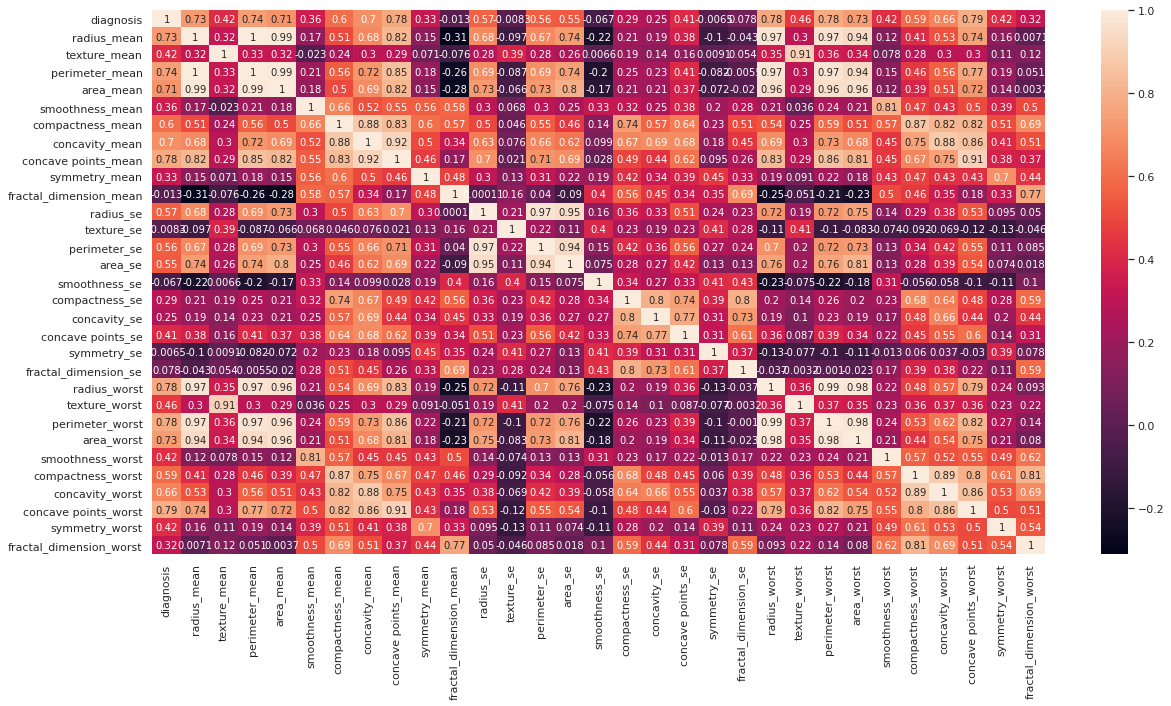

In [20]:
plt.figure(figsize=(20,10))
sns.heatmap(cancer.corr(),annot=True)

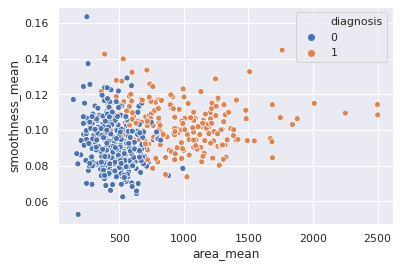

In [21]:
sns.scatterplot(x='area_mean',y='smoothness_mean',hue='diagnosis',data=cancer)

In [22]:
cancer.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [23]:
features = ['radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst']

In [24]:
X =cancer.iloc[:,1:32].values
y =cancer['diagnosis']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=22,stratify=y)

<a id="4"></a>
<h2 style='font-size:30px;background:black; border:0; color:white'><center>FEATURE SCALING</center><h2>

<font size='3'>Because Support Vector Machine (SVM) optimization occurs by minimizing the decision vector w, the optimal hyperplane is influenced by the scale of the input features and it's therefore recommended that data be standardized (mean 0, var 1) prior to SVM model training.</font>

In [26]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)

<a id="5"></a>
<h2 style='font-size:30px;background:black; border:0; color:white'><center>MODEL BUILDING</center><h2>

In [27]:
model = SVC(kernel='linear')
model.fit(X_train,y_train)

SVC(kernel='linear')

In [28]:
y_pred = model.predict(X_test)

<a id="6"></a>
<h2 style='font-size:30px;background:black; border:0; color:white'><center>MODEL EVALUATION</center><h2>

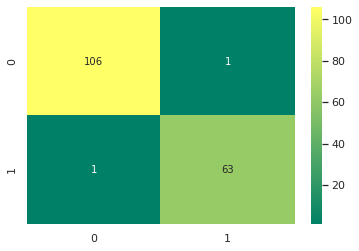

In [29]:
cnf = confusion_matrix(y_test,y_pred)
sns.heatmap(cnf,annot=True,cmap='summer',fmt='g')

In [30]:
acc = accuracy_score(y_test,y_pred)
print("Accuracy:",acc)

Accuracy: 0.9883040935672515


In [31]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       107
           1       0.98      0.98      0.98        64

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171



No doubt we have good accuracy of 98% but let's see if our model can get better with parameter tuning! Let's go 

<a id="7"></a>
<h2 style='font-size:30px;background:black; border:0; color:white'><center>PARAMETER TUNING</center><h2>

In [32]:
param_grid={'C':[0.1,1,10,100,1000],
            'gamma':[1,0.1,0.01,0.001,0.0001],
            'kernel':['rbf']}

In [33]:
grid= GridSearchCV(SVC(),param_grid,refit=True,verbose=4)
grid.fit(X_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] C=0.1, gamma=1, kernel=rbf ......................................
[CV] .......... C=0.1, gamma=1, kernel=rbf, score=0.625, total=   0.0s
[CV] C=0.1, gamma=1, kernel=rbf ......................................
[CV] .......... C=0.1, gamma=1, kernel=rbf, score=0.625, total=   0.0s
[CV] C=0.1, gamma=1, kernel=rbf ......................................
[CV] .......... C=0.1, gamma=1, kernel=rbf, score=0.625, total=   0.0s
[CV] C=0.1, gamma=1, kernel=rbf ......................................
[CV] .......... C=0.1, gamma=1, kernel=rbf, score=0.633, total=   0.0s
[CV] C=0.1, gamma=1, kernel=rbf ......................................
[CV] .......... C=0.1, gamma=1, kernel=rbf, score=0.633, total=   0.0s
[CV] C=0.1, gamma=0.1, kernel=rbf ....................................
[CV] ........ C=0.1, gamma=0.1, kernel=rbf, score=0.900, total=   0.0s
[CV] C=0.1, gamma=0.1, kernel=rbf ....................................
[CV] ........ C

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s


[CV] ..... C=0.1, gamma=0.0001, kernel=rbf, score=0.625, total=   0.0s
[CV] C=0.1, gamma=0.0001, kernel=rbf .................................
[CV] ..... C=0.1, gamma=0.0001, kernel=rbf, score=0.625, total=   0.0s
[CV] C=0.1, gamma=0.0001, kernel=rbf .................................
[CV] ..... C=0.1, gamma=0.0001, kernel=rbf, score=0.625, total=   0.0s
[CV] C=0.1, gamma=0.0001, kernel=rbf .................................
[CV] ..... C=0.1, gamma=0.0001, kernel=rbf, score=0.633, total=   0.0s
[CV] C=0.1, gamma=0.0001, kernel=rbf .................................
[CV] ..... C=0.1, gamma=0.0001, kernel=rbf, score=0.633, total=   0.0s
[CV] C=1, gamma=1, kernel=rbf ........................................
[CV] ............ C=1, gamma=1, kernel=rbf, score=0.625, total=   0.0s
[CV] C=1, gamma=1, kernel=rbf ........................................
[CV] ............ C=1, gamma=1, kernel=rbf, score=0.625, total=   0.0s
[CV] C=1, gamma=1, kernel=rbf ........................................
[CV] .

[Parallel(n_jobs=1)]: Done 125 out of 125 | elapsed:    1.0s finished


GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=4)

In [34]:
grid.best_params_

{'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}

In [35]:
grid.best_score_

0.9749367088607596

In [36]:
g_pred = grid.predict(X_test)

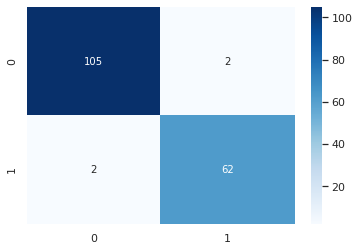

In [37]:
g_cnf = confusion_matrix(y_test,g_pred)
sns.heatmap(g_cnf,annot=True,fmt='g',cmap='Blues')

In [38]:
g_acc = accuracy_score(y_test,g_pred)
print("Accuracy with GridSearch:",g_acc)

Accuracy with GridSearch: 0.9766081871345029


In [39]:
print(classification_report(y_test,g_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       107
           1       0.97      0.97      0.97        64

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



Our model has done best with 98% accuracy without parameter tuning!

<a id="8"></a>
<h2 style='font-size:30px;background:black; border:0; color:white'><center>FEATURE IMPORTANCE</center><h2>

In [40]:
coef= model.coef_
coeffs = np.squeeze(coef)
coeffs

array([ 0.23463524, -0.02721934,  0.26579436,  0.26177093,  0.04181737,
       -0.4698767 ,  0.63301254,  0.39352156,  0.31430033, -0.2808655 ,
        0.70316845, -0.27917949,  0.21223191,  1.10398539,  0.39494297,
       -0.5604031 , -0.10315375,  0.37468872, -0.17339705, -0.71163786,
        0.59167568,  1.09187142,  0.49122216,  0.8525706 ,  0.19158561,
        0.01121302,  0.66293921,  0.35053975,  0.29471587,  0.9004685 ])

In [41]:
coefs = pd.DataFrame({"Features":features,"Coefficients":coeffs})
feature_imp = coefs.sort_values(by='Coefficients',ascending=False)

In [42]:
feature_imp

,Features,Coefficients
13,area_se,1.103985
21,texture_worst,1.091871
29,fractal_dimension_worst,0.900468
23,area_worst,0.852571
10,radius_se,0.703168
26,concavity_worst,0.662939
6,concavity_mean,0.633013
20,radius_worst,0.591676
22,perimeter_worst,0.491222
14,smoothness_se,0.394943


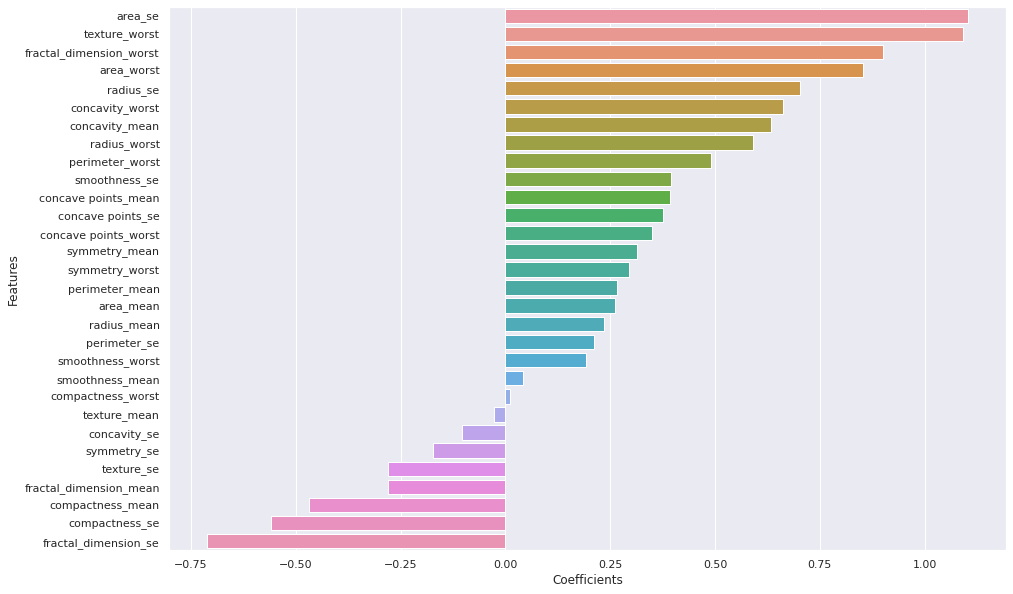

In [43]:
plt.figure(figsize=(15,10))
sns.barplot(y='Features',x='Coefficients',data=feature_imp)

## [GO TO TOP](#10)

<center><img src="https://encrypted-tbn0.gstatic.com/images?q=tbn%3AANd9GcQpTjNIwP4--vaPwInGxqMufHlWLQjCnRPLEg&usqp=CAU![image.png](attachment:image.png)"><center

<center><img src="https://images-na.ssl-images-amazon.com/images/I/613f9N0BiJL._SL1500_.jpg"></center>